In [ ]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.dates as mdates
import matplotlib.units as munits
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA

import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})

INSPER_RED = '#E50505'
INSPER_TURQUESA = '#3ACC9F'
INSPER_AMARELO = '#FFCC00'
INSPER_GRAY = '#5B5B5B'

In [ ]:
pmc = pd.read_csv("https://github.com/padsInsper/202632-fa/releases/download/data/pmc_volume_uf.csv")

In [ ]:
MINHA_UF = "Minas Gerais" 

df_sf = (
    pmc.query("uf == @MINHA_UF")
    .rename(columns={"uf": "unique_id", "data": "ds", "volume_idx": "y"})
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)

#Criar uma nova variavel date-time para as visualizações
df_sf['t'] = pd.to_datetime(df_sf['ds'],format="%Y-%m-%d")

#Redefinindo o index
df_sf = df_sf.set_index('ds')

df_sf.tail()

,unique_id,y,t
ds,,,
2025-10-01,Minas Gerais,110.41414,2025-10-01
2025-11-01,Minas Gerais,108.65351,2025-11-01
2025-12-01,Minas Gerais,119.81690,2025-12-01
2026-01-01,Minas Gerais,102.38965,2026-01-01
2026-02-01,Minas Gerais,96.32129,2026-02-01


In [ ]:
# Série completa 
fig = px.line(
    df_sf, y='y',
    labels={'ds': 'Data', 'y': 'PMC'},
    template='plotly_white'
)
fig.update_traces(line_color=INSPER_RED)
fig.update_layout(
    title = dict(
        text = 'PMC - Série completa para MG',
        subtitle = dict(text = "Base 2022 = 100"),
    ),
    font_family="Inter",
    title_font_size=18,
    hovermode='x unified'
)
fig.show()

In [ ]:
# Últimos 36 meses
fig = px.line(
    df_sf[df_sf['t'] >= '2023-01-01'], y='y', x='t',
    labels={'t': 'Data', 'y': 'PMC'},
    template='plotly_white'
)
fig.update_traces(line_color=INSPER_RED)
fig.update_layout(
    title = dict(
        text = 'PMC - Últimos 36 meses para MG',
        subtitle = dict(text = "Base 2022 = 100"),
    ),
    font_family="Inter",
    title_font_size=18,
    hovermode='x unified'
)
fig.show()

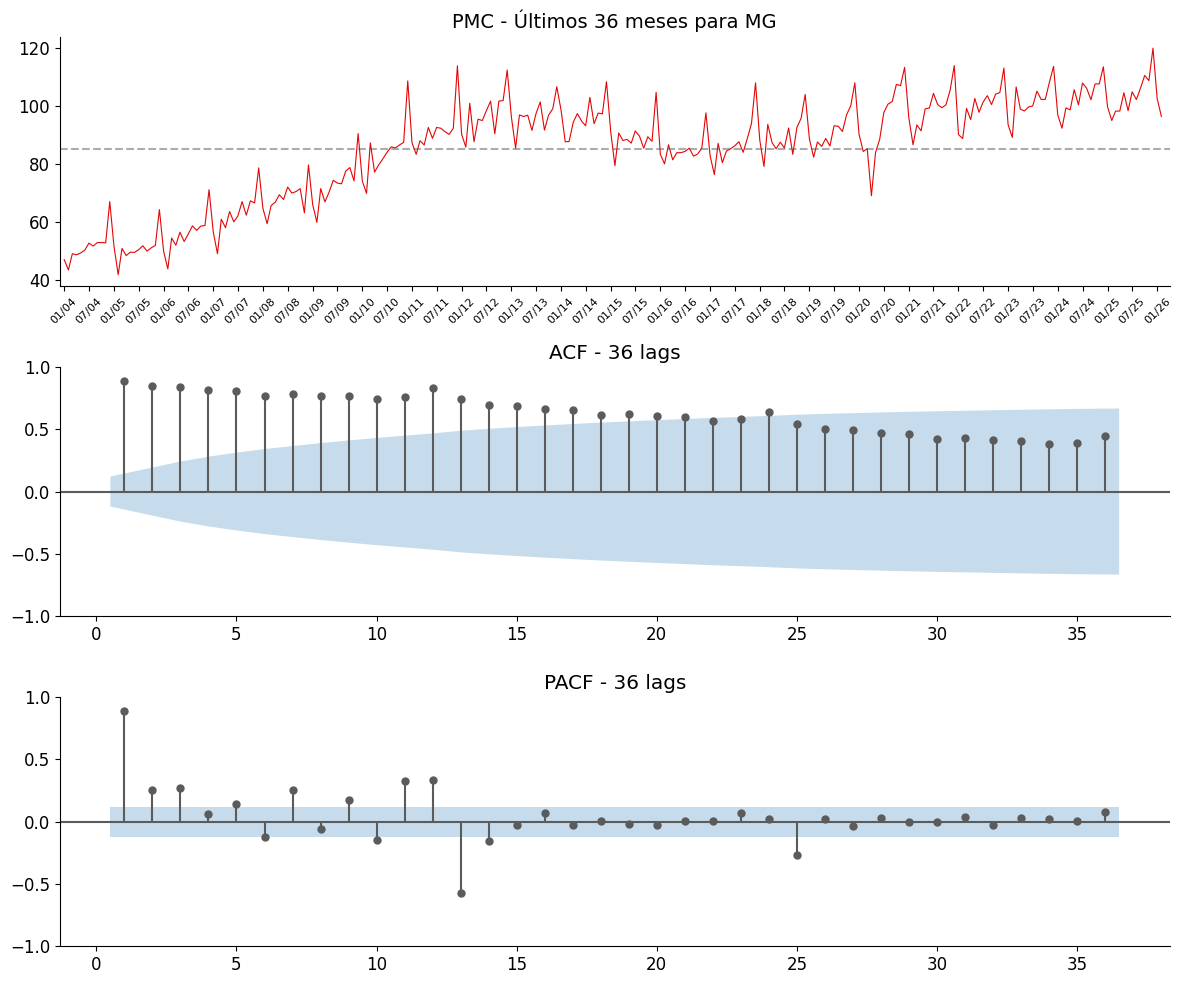

In [ ]:
#Comparação
def plotar_diagnostico(serie_y, serie_x, lags=36):
    """Plota série + ACF + PACF em layout 3x1"""
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Série
    axes[0].plot(serie_x, serie_y, color=INSPER_RED, linewidth=0.8)
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%y'))
    axes[0].tick_params(axis='x', labelrotation=45, labelsize=8)
    axes[0].set_xlim([datetime.date(2003, 12, 1), datetime.date(2026, 4, 2)])
    axes[0].axhline(y=serie_y.mean(), color=INSPER_GRAY, linestyle='--', alpha=0.5)
    axes[0].set_title('PMC - Últimos 36 meses para MG', fontsize=14)

    # ACF
    plot_acf(serie_y.dropna(), ax=axes[1], lags=lags, zero=False,
             color=INSPER_GRAY, vlines_kwargs={'colors': INSPER_GRAY})
    axes[1].set_title('ACF - 36 lags')

    # PACF
    plot_pacf(serie_y.dropna(), ax=axes[2], lags=lags, zero=False,
              color=INSPER_GRAY, vlines_kwargs={'colors': INSPER_GRAY})
    axes[2].set_title('PACF - 36 lags')

    plt.tight_layout()
    plt.show()

plotar_diagnostico(df_sf['y'], df_sf['t'])

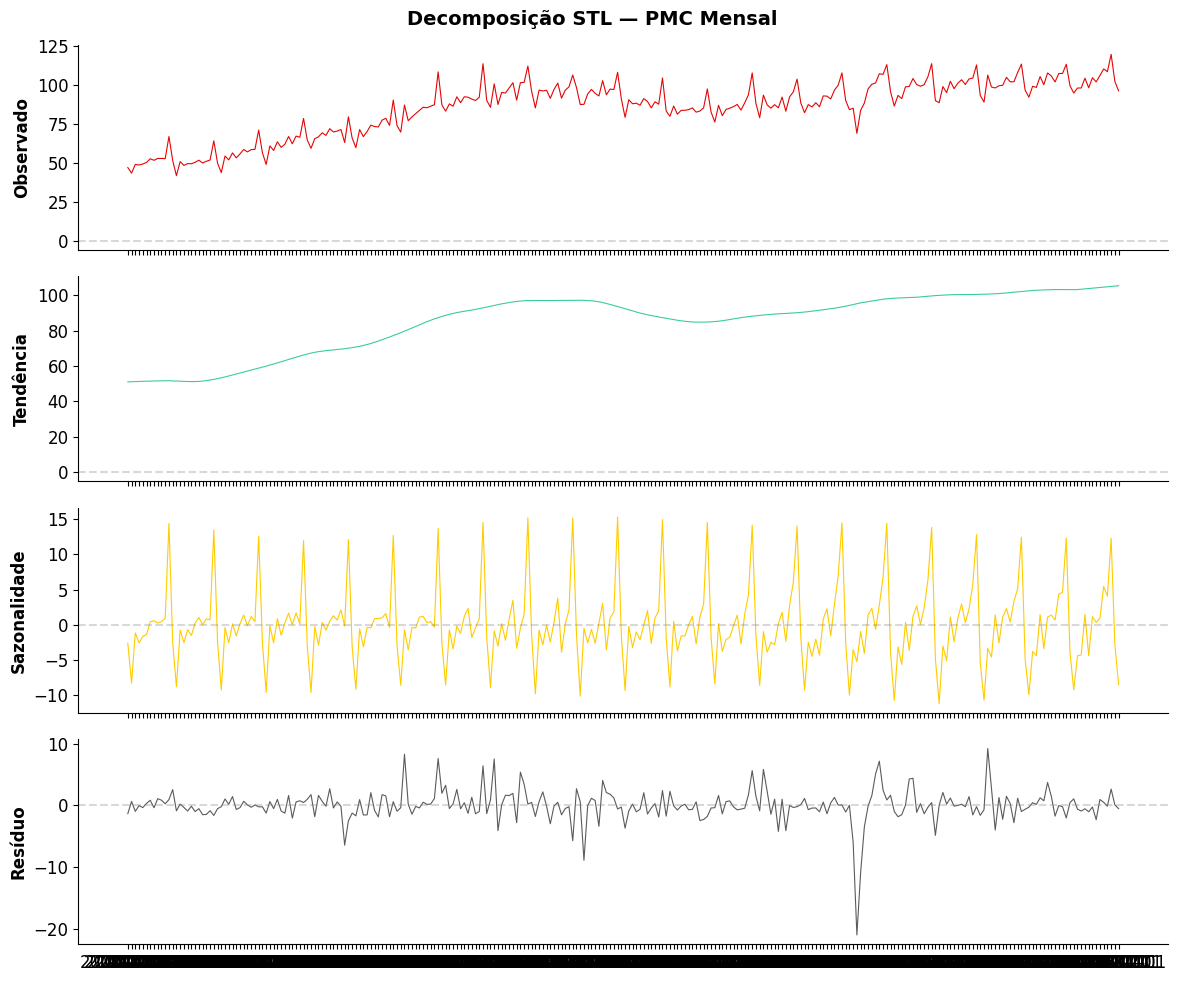

In [ ]:
# Decomposição STL
pmc_mensal = df_sf['y']
pmc_mensal = pmc_mensal.interpolate()

stl = STL(pmc_mensal, period=12, robust=True)
resultado = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

componentes = {
    'Observado': pmc_mensal,
    'Tendência': resultado.trend,
    'Sazonalidade': resultado.seasonal,
    'Resíduo': resultado.resid
}
cores = [INSPER_RED, INSPER_TURQUESA, INSPER_AMARELO, INSPER_GRAY]

for ax, (nome, comp), cor in zip(axes, componentes.items(), cores):
    ax.plot(comp, color=cor, linewidth=0.8)
    ax.set_ylabel(nome, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

plt.suptitle('Decomposição STL — PMC Mensal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#Testes de raiz unitária
def testar_estacionariedade(serie, nome = "Série"):
    #Aplica testes ADF e KPSS e interpreta resultados
    print(f"{'='*50}")
    print(f"Testes de Estacionariedade — {nome}")
    print(f"{'='*50}\n")

    # ADF
    resultado_adf = adfuller(serie.dropna(), autolag='AIC')
    print(f"Teste ADF (H0: raiz unitária)")
    print(f"  Estatística: {resultado_adf[0]:.4f}")
    print(f"  p-valor:     {resultado_adf[1]:.4f}")
    print(f"  Lags usados: {resultado_adf[2]}")

    if resultado_adf[1] < 0.05:
        print(f"  → Rejeita H0: evidência de estacionariedade\n")
    else:
        print(f"  → Não rejeita H0: evidência de raiz unitária\n")

    # KPSS
    resultado_kpss = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f"Teste KPSS (H0: estacionária)")
    print(f"  Estatística: {resultado_kpss[0]:.4f}")
    print(f"  p-valor:     {resultado_kpss[1]:.4f}")

    if resultado_kpss[1] < 0.05:
        print(f"  → Rejeita H0: evidência de não-estacionariedade\n")
    else:
        print(f"  → Não rejeita H0: evidência de estacionariedade\n")

    # Conclusão conjunta
    adf_estacionaria = resultado_adf[1] < 0.05
    kpss_estacionaria = resultado_kpss[1] >= 0.05

    if adf_estacionaria and kpss_estacionaria:
        print("CONCLUSÃO: Série provavelmente ESTACIONÁRIA")
    elif not adf_estacionaria and not kpss_estacionaria:
        print("CONCLUSÃO: Série provavelmente NÃO ESTACIONÁRIA")
    else:
        print("CONCLUSÃO: Resultados INCONCLUSIVOS — análise adicional necessária")

testar_estacionariedade(df_sf['y'], 'PMC mensal')

Testes de Estacionariedade — PMC mensal

Teste ADF (H0: raiz unitária)
  Estatística: -1.9005
  p-valor:     0.3318
  Lags usados: 14
  → Não rejeita H0: evidência de raiz unitária

Teste KPSS (H0: estacionária)
  Estatística: 1.9129
  p-valor:     0.0100
  → Rejeita H0: evidência de não-estacionariedade

CONCLUSÃO: Série provavelmente NÃO ESTACIONÁRIA


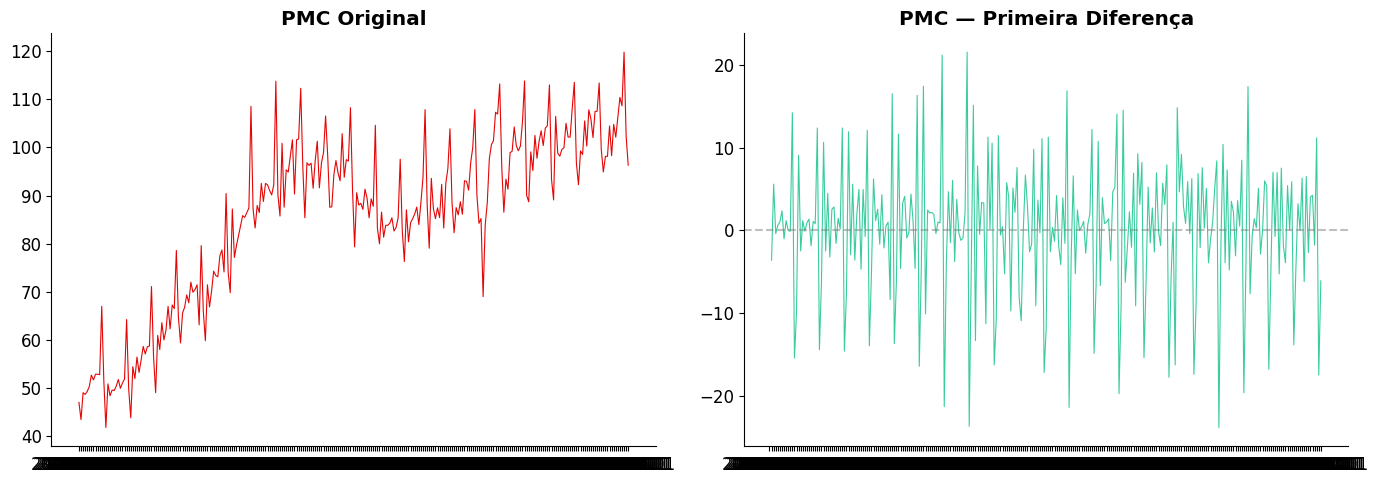

Testes de Estacionariedade — PMC (1ª diferença)

Teste ADF (H0: raiz unitária)
  Estatística: -3.6197
  p-valor:     0.0054
  Lags usados: 13
  → Rejeita H0: evidência de estacionariedade

Teste KPSS (H0: estacionária)
  Estatística: 0.2096
  p-valor:     0.1000
  → Não rejeita H0: evidência de estacionariedade

CONCLUSÃO: Série provavelmente ESTACIONÁRIA


In [ ]:
# Diferenciação da série
df_diff = df_sf
df_diff['diff_1'] = df_diff['y'].diff().dropna()
df_diff['diff_1'] = df_diff['diff_1'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_sf['y'], color=INSPER_RED, linewidth=0.8)
axes[0].set_title('PMC Original', fontweight='bold')

axes[1].plot(df_diff['diff_1'], color=INSPER_TURQUESA, linewidth=0.8)
axes[1].set_title('PMC — Primeira Diferença', fontweight='bold')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Testes na série diferenciada
testar_estacionariedade(df_diff['diff_1'], 'PMC (1ª diferença)')

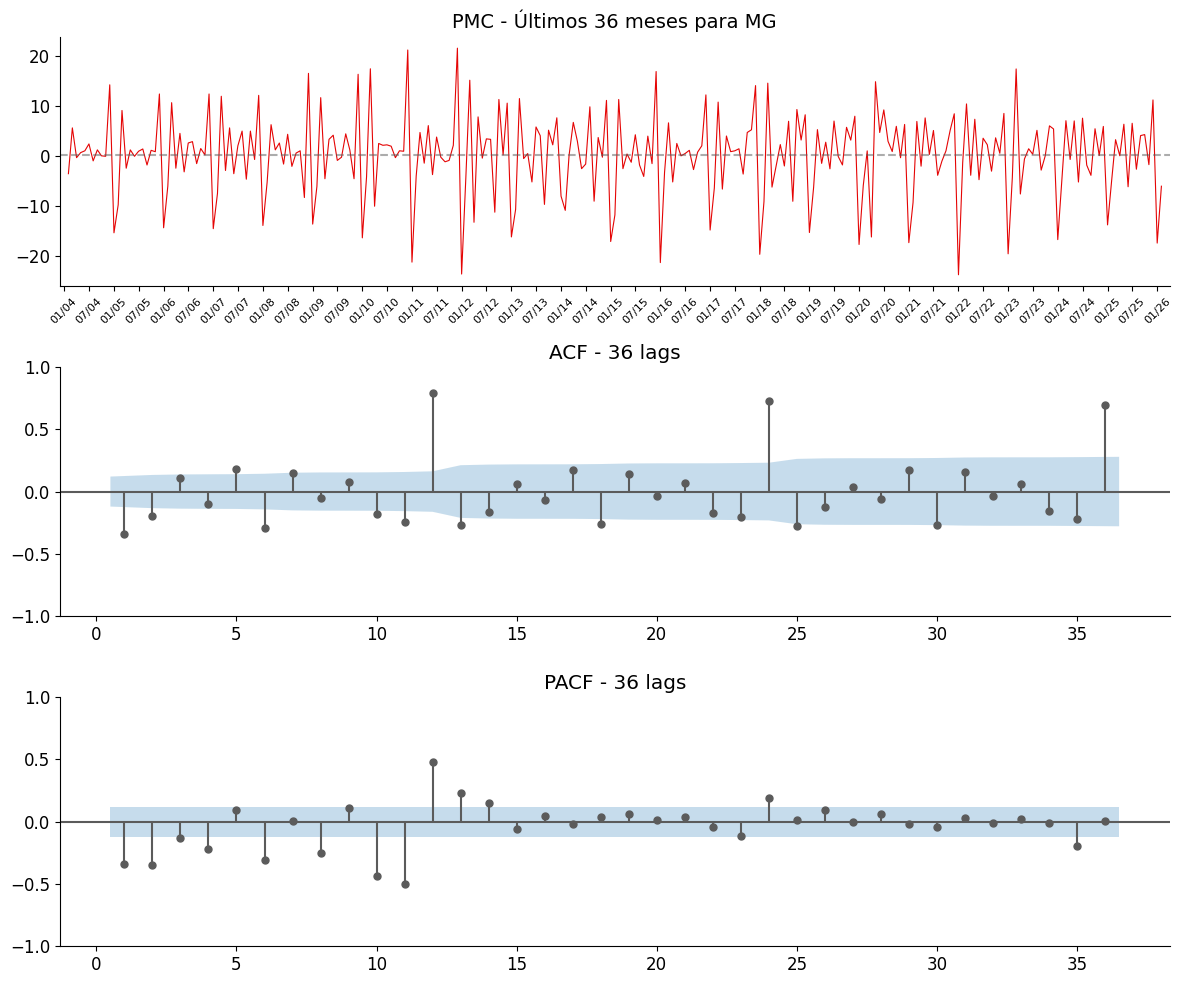

In [ ]:
# Diagnóstico da série diferenciada
plotar_diagnostico(df_diff['diff_1'], df_diff['t'])

In [ ]:
# Ajuste de SARIMA via AutoARIMA
# Preparar dados no formato Nixtla (unique_id, ds, y)
df_sarima = (
    pmc.query("uf == @MINHA_UF")
    .rename(columns={"uf": "unique_id", "data": "ds", "volume_idx": "y"})
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)
df_sarima['ds'] = pd.to_datetime(df_sarima['ds'],format="%Y-%m-%d")

# Ajustar AutoARIMA com sazonalidade mensal
sf = StatsForecast(models=[AutoARIMA(season_length=12)], freq='MS', n_jobs=1)
sf.fit(df = df_sarima)

# Ver modelo selecionado
fitted = sf.fitted_[0, 0]
print("Modelo selecionado:")
print(fitted.model_['arma'])  # (p, q, P, Q, s, d, D)

print(f"\nAICc: {fitted.model_['aicc']:.2f}")
print(f"Ordem (p,d,q): ({fitted.model_['arma'][0]}, {fitted.model_['arma'][5]}, {fitted.model_['arma'][1]})")
print(f"SARIMA({fitted.model_['arma'][0]},{fitted.model_['arma'][5]},{fitted.model_['arma'][1]})({fitted.model_['arma'][2]},{fitted.model_['arma'][6]},{fitted.model_['arma'][3]})[{fitted.model_['arma'][4]}]")

Modelo selecionado:
(3, 2, 1, 1, 12, 1, 1)

AICc: 1357.86
Ordem (p,d,q): (3, 1, 2)
SARIMA(3,1,2)(1,1,1)[12]


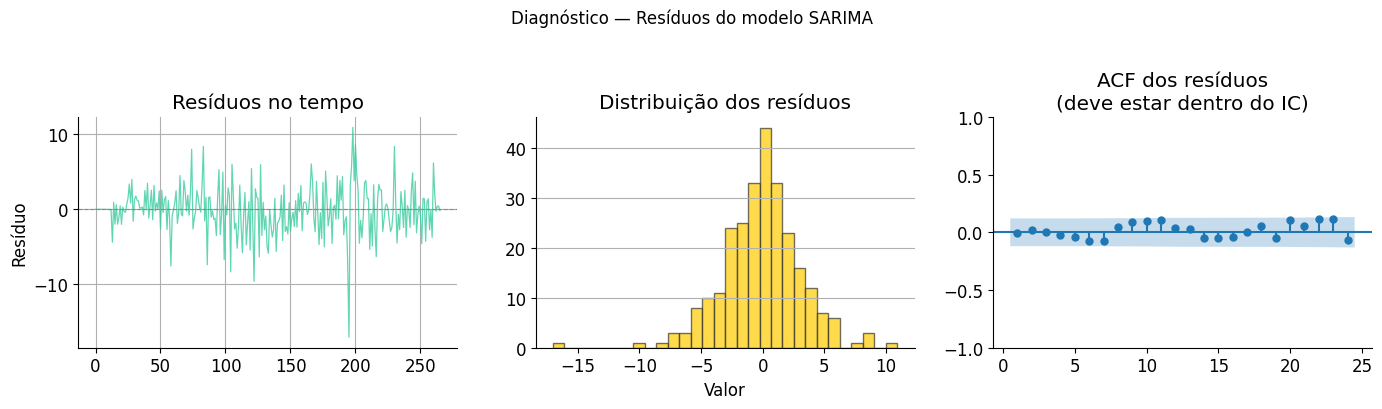

✅ Se a ACF dos resíduos estiver dentro do IC → modelo bem ajustado!


In [ ]:
#Diagnóstico dos resíduos
modelo = sf.fitted_[0, 0].model_
residuos = pd.Series(modelo.get('residuals', []))

if len(residuos) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Resíduos no tempo
    axes[0].plot(residuos.values, color=INSPER_TURQUESA, linewidth=0.9, alpha=0.8)
    axes[0].axhline(0, color='#888', linestyle='--', linewidth=0.8)
    axes[0].set_title('Resíduos no tempo')
    axes[0].set_ylabel('Resíduo'); axes[0].grid(True)

    # Histograma
    axes[1].hist(residuos, bins=30, color=INSPER_AMARELO, alpha=0.7, edgecolor='#333')
    axes[1].set_title('Distribuição dos resíduos')
    axes[1].set_xlabel('Valor'); axes[1].grid(True, axis='y')

    # ACF dos resíduos — deve ser ruído branco
    plot_acf(residuos, ax=axes[2], lags=24, zero=False,
             title='ACF dos resíduos\n(deve estar dentro do IC)')

    plt.suptitle('Diagnóstico — Resíduos do modelo SARIMA', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    print("✅ Se a ACF dos resíduos estiver dentro do IC → modelo bem ajustado!")
else:
    print("(Resíduos não disponíveis nesta versão do statsforecast)")

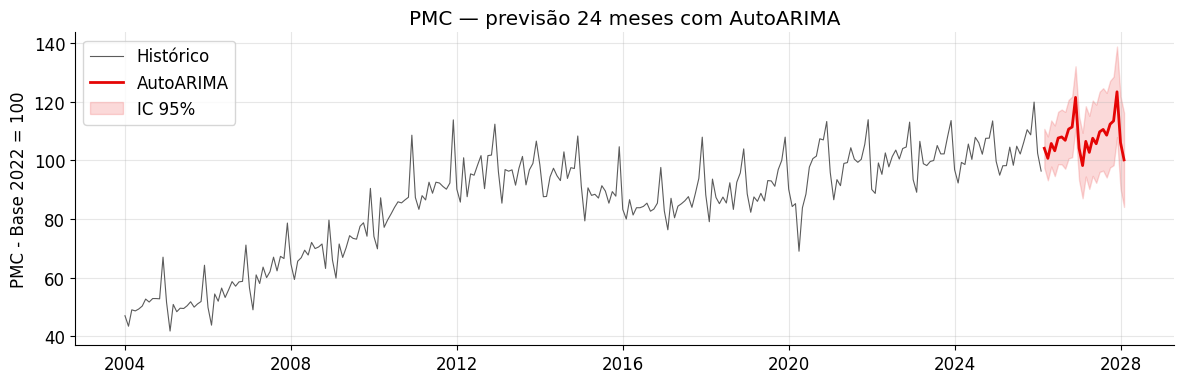

In [ ]:
#Previsão de 24 meses
forecast = sf.predict(h=24, level=[80, 95])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_sarima['ds'], df_sarima['y'], color='#5B5B5B', linewidth=0.8, label='Histórico')
ax.plot(forecast['ds'], forecast['AutoARIMA'], color='#E50505', linewidth=2, label='AutoARIMA')
ax.fill_between(forecast['ds'],
                forecast['AutoARIMA-lo-95'], forecast['AutoARIMA-hi-95'],
                alpha=0.15, color='#E50505', label='IC 95%')
ax.set_title('PMC — previsão 24 meses com AutoARIMA')
ax.set_ylabel('PMC - Base 2022 = 100'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()